## Analyzing MESA output with TULIPS - Lab 2

TULIPS is open-source python software, you can find more information and tutorials about it [here](https://astro-tulips.readthedocs.io/en/latest/installation.html).

## Install TULIPS
The installation on the Google collab virtual machine can take a few minutes (note that it is normally only installed once when you install it on your own laptop).

In [ ]:
!pip install astro-tulips

In [ ]:
# Interactive matplotlib plotting for jupyter lab
%matplotlib inline

# Packages you will need for this tutorial
import matplotlib.pyplot as plt
import mesaPlot as mp
import tulips
import numpy as np
from IPython.display import Video

We now have all the packages and software installed that we need for this tutorial!

## Loading data from the MESA model

Upload the MESA output files. To do so:
1. Download all the files in the google drive link [here](https://drive.google.com/file/d/1TdQyhbeAyR26h06TjoVqOkXcX-lhDOrm/view?usp=sharing) as a zipped file.
2. Upload the files as shown below (this can take some time)

In [ ]:
from google.colab import files
uploaded = files.upload() # This opens an option to upload files. Upload the zipped files here

Saving Profiles.zip to Profiles.zip


You can see the zipped file appear in the `Files` side bar on the left (with the folder icon). Let's unzip the files - Make sure to add the name of your uploaded file

In [ ]:
import zipfile
# Replace by the name of your uploaded file
with zipfile.ZipFile("Profiles.zip", "r") as zip_ref:
  zip_ref.extractall("Profiles2")

Now that the data has been uploaded and unzipped, we can analyze it. Let's read the output from the donor star

In [ ]:
DONOR_DIR = "/content/Profiles2/Profiles/LOGS1/" # Change to your local path of the uploaded file

m1 = mp.MESA() # Create MESA object for the donor star
m1.log_fold = DONOR_DIR # Find the data file
m1.loadHistory(filename_in=DONOR_DIR + "history1.data") # Load the MESA history  data

**Task:** Now load data from the accretor star. Call the object containing the data `m2`

In [ ]:
ACCRETOR_DIR = "/content/Profiles2/Profiles/LOGS2/" # Change to your local path of the uploaded file

# Load data from secondary (accretor) star
m2 = mp.MESA() # Create MESA object containing data from the accretor
m2.log_fold = ACCRETOR_DIR
m2.loadHistory(filename_in=ACCRETOR_DIR + "history2.data")

### Accessing properties

After the history output file has been loaded, properties such as the mass, age or radius of the star can be accessed through the `hist` property. These are all stored as lists of values (numpy arrays).

To have a look at the different properties that are stored, type `m1.hist.` and press `Tab`. This will show you a list of the information that can be accessed. You can use these properties to make simple plots. For more documentation about `mesaPlot`, have a look at the [mesaPlot](https://github.com/rjfarmer/mesaplot) GitHub page.

In [ ]:
star_age = m1.hist.star_age # Access star age in years
center_h1 = m1.hist.center_h1 # Access the mass fraction of hydrogen in the center of the star
log_R = m1.hist.log_R # Access star's log_10 radius in solar radius units.
R = 10**log_R # To find the radius, use the power 10
lg_mtr = m1.hist.lg_mtransfer_rate # Log mass transfer rate in Msun/yr

Let's check the radius at the beginning of the simulation (ZAMS)

In [ ]:
print(R[0])

2.54762261554588


Let's check the radius at the end of the simulation

In [ ]:
print(R[-1])

0.04500390477753321


**Task:** Can you find the total mass of the donor and accretor star at the begining and end of the simulation?



The default unit is in solar masses

In [ ]:
print(m1.hist.star_mass[0], m1.hist.star_mass[-1])

4.999993353102518 0.8289114257236612


In [ ]:
print(m2.hist.star_mass[0], m2.hist.star_mass[-1])

3.12499955917222 7.25868069768549


**Q:** What has changed and why?

**A:** The donor star has transferred about 4Msun of its outer layers to the accretor star

# Your first TULIPS plot

Now let's use TULIPS to check the apparent size and color of the donor star at different times in its evolution

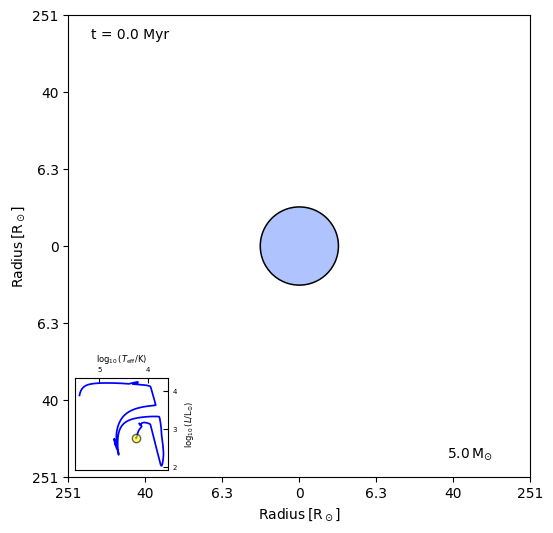

In [ ]:
fig, ax = tulips.perceived_color(m1, time_ind=0, show_hrd_ticks_and_labels=True,
                                 fig_size=(6,6))



> **Note**: `time_ind` refers to an index that follows every model stored in a MESA `history.data` file. This means the first model is at index 0 and the last is at index -1. It depends on your model which age this corresponds to. The powerful thing about `time_ind` is that it lets you find out some specific times very easily through numpy functions. For example, if you want to visualize a star at the point moment when it finishes hydrogen burning (end of the main seequence), you can look for the index where the central hydrogen mass fraction is very small, like `end_hburn_index = np.where(m1.hist.center_h1 < 1e-4)[0][0]`.


### Find the apparent size and color of the star when it is halfway through hydrogen burning

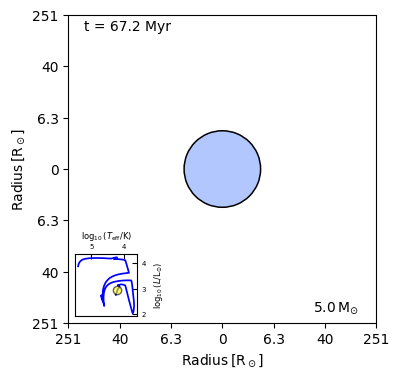

In [ ]:
ind = np.where(m1.hist.center_h1 < 0.5 * m1.hist.center_h1[0])[0][0]

fig, ax = tulips.perceived_color(m1, time_ind=ind, show_hrd_ticks_and_labels=True)


## Your first TULIPS animation

By changing the `time_ind` property from one number to an array, we can now create a video of the evolution of the star that will be saved as `output_name.mp4`

In [ ]:
fig, ax = tulips.perceived_color(m1, # MESA model
                                 time_ind=(0, -1, 20), # Index range considered for the movie: from start to end, every 10 model_numbers
                                 fig_size=(5,5),
                       show_hrd_ticks_and_labels=True,
                       output_fname="perceived-color-donor" # Output file name in .mp4 format
                       )
plt.close(fig=fig)

  0%|          | 0/323 [00:00<?, ?it/s]

Creating animation


In [ ]:
# Reading the output Video created
Video("perceived-color-donor.mp4", embed=True, width=600, height=600)

**Task:** Observe what happens at the moment when the star reaches its maximum radius.

*   What happens to the luminosity of the star?
*   What happens to its color (or effective temperature)?

**Answer**:


*   The luminosity drops by more than an order of magitude, then increases again by the same order during mass transfer as the stars internal energy is used to re-expand to fill its Roche lobe instead of being radiated away
*   The color of the star changes rapidly from reddish to blue as the star loses mass and the hotter inner layers are exposed.



## Evolution of the accretor star
**Task:** Check the perceived color evolution of the accretor star



In [ ]:
fig, ax = tulips.perceived_color(m2, time_ind=(0, -1, 20), fig_size=(5,5),
                       show_hrd_ticks_and_labels=True,
                       output_fname="perceived-color-accretor")
plt.close(fig=fig)

  0%|          | 0/323 [00:00<?, ?it/s]

Creating animation


In [ ]:
# Reading the output Video created
Video("perceived-color-accretor.mp4", embed=True, width=700, height=700)

**Questions:**
* What happens to the radius of the star?
* What happens to its color (or effective temperature)?

**Answers**

*   The radius increases rapidly, then decreases again
*   The star becomes cooler (redder), then bluer again as it get out of thermal equilibrium while accreting mass and later regains thermal equilibrium and behaves like an initally higher-mass star



# Checking the change in interior nuclear energy generation and energy loss

We can also observe the processes that take place inside the star and determine its evolution. TULIPS creates a visualization of these processes (usually shown as a Kippenhahn diagram) by showing the interior structure as nested circles whose radius is proportional to the enclosed mass within the circle. The outer circle is proportional to the total mass of the star.


### For the donor

In [ ]:
fig, ax = tulips.energy_and_mixing(m1, # MESA model of the donor
                                   time_ind=(0, -1, 20), # Index range considered for the movie: from start to end, every 10 model_numbers
                                   output_fname="energy_movie_donor" # Video file name
                         )
plt.close(fig=fig)

  0%|          | 0/323 [00:00<?, ?it/s]

Creating movie...


In [ ]:
# Reading the output Video created
Video("energy_movie_donor.mp4", embed=True, width=700, height=700)

**Questions**
*   Which changes in mass and in energy generation do you observe?

* At which points do you observe changes in mass?

*  What is happening at the end of the simulation?



**Answers**

*   The mass decreases dramatically during the evolution at the moment of the luminosity drop. This is the onset of mass transfer. Energy is first generated at the center (H burning), then in a shell (H shell burning). Later on, He ignites in the center and H continues to burn in a shell, before it vanishes as the star loses its hydrogen layers. At the very end of the simulation, we can observed energy losses in the center and a strong burning shell that corresponds to helium shell burning.
* Mass is lost during the drop in luminosity phase (mass transfer) and towards the end of the simulation (stellar winds)
* At the end of the simulation, neutrino losses at the center lead to a net energy loss in the center while helium burns in a shell

### For the accretor

**Task:** Check the change in the energy generation for the accretor from the onset of mass transfer to the end of the simulation

In [ ]:
fig, ax = tulips.energy_and_mixing(m2, # MESA model of the donor
                                   time_ind=(0, -1, 20),
                                   output_fname="energy_movie_accretor" # Video file name
                         )
plt.close(fig=fig)

  0%|          | 0/323 [00:00<?, ?it/s]

Creating movie...


In [ ]:
# Reading the output Video created
Video("energy_movie_accretor.mp4", embed=True, width=700, height=700)

**Questions**
*   Which changes in mass and in energy generation do you observe?

* At which points do you observe changes in mass?

*  What is happening at the end of the simulation?


**Answers**

*   The star has a dramatic increase in total mass. The energy generation region increases in mass and becomes more energetic
*   The star increases in mass during mass transfer (phase when the star suddently expands in radius)
* At the end of the simulation, the star has recovered a stable thermal structure and rejuvenated. It now behaves like an initially higher-mass star



## Checking the change in chemical composition

We can look at the interior composition of stars and check how mass transfer affects their composition. The TULIPS diagrams show which isotopes are present in the stellar model, but also how the composition changes from the center to the stellar surface. Similar to the other diagrams, TULIPS represents the stellar object as a circle, divided into rings. To show the interior composition, TULIPS uses nested pie-charts. For every ring (layer inside the star), it shows the mass fraction of each isotope present in that layer by using different colors.





### Accretor star

In [ ]:
fig, ax = tulips.chemical_profile(m2,
                                  axis_lim=1.7, # Rescaling the axis limits to show the accretor star
                        time_ind=(0, -1, 1), fig_size=(4,4),
                        hrd_inset=True, num_rings=200,
                        output_fname="acc_comp",
                        fps=5 # frame per second
                        )
plt.close(fig=fig)

/content/Profiles2/Profiles/LOGS2//profile1.data
Loading profiles, this may take some time...


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Creating movie...


In [ ]:
# Reading the output Video created
Video("acc_comp.mp4", embed=True, width=700, height=700)


* How does the composition change with time and in which layers of the star?
* What is the biggest change induced by mass transfer?
* How different is this evolution compared to a single star?

### Donor star

Check the change in composition in this star

/content/Profiles2/Profiles/LOGS1//profile76.data


(<Figure size 400x400 with 3 Axes>, <Axes: >)

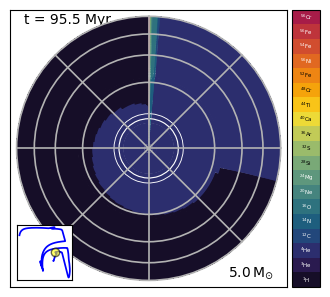

In [ ]:
# Composition at the end of hydrogen burning
ind = np.where(m1.hist.center_h1 < 1e-4)[0][0]
tulips.chemical_profile(m1, time_ind=ind, fig_size=(4,4),
                        num_rings=200)

Creating an animation of the change in composition from start to end of the simulation

In [ ]:
fig, ax = tulips.chemical_profile(m1, time_ind=(0, -1, 1), fig_size=(4,4),
                                  hrd_inset=False, num_rings=200,
                                  output_fname="donor_comp",
                                  fps=5 # frame per second
                                  )
plt.close(fig=fig)

/content/Profiles2/Profiles/LOGS1//profile1.data
Loading profiles, this may take some time...


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Creating movie...


In [ ]:
# Reading the output Video created
Video("donor_comp.mp4", embed=True, width=700, height=700)


* How does the composition change with time and in which layers of the star?
* What is the biggest change induced by mass transfer?
* How different is this evolution compared to a single star?

